<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 174.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 213.0 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 170.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 159.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 168.9 MB/s eta 0:00:00


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-02-25 19:29:26--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
169.63.118.104ourses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  45.0MB/s    in 3.4s    

2026-02-25 19:29:29 (44.9 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



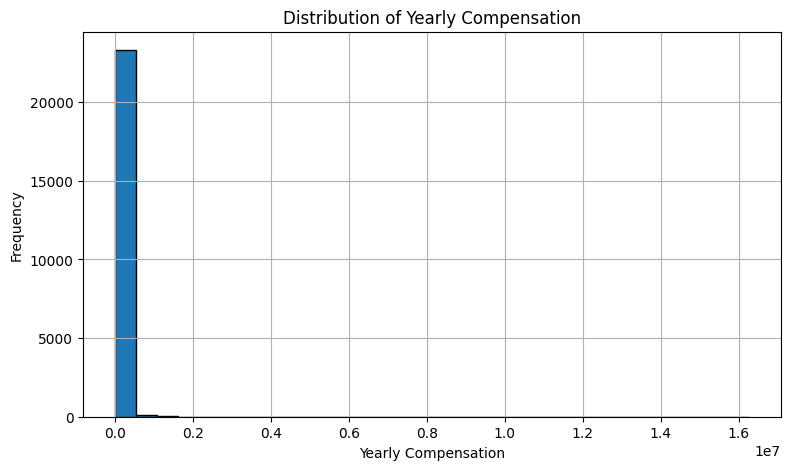

In [7]:
## Write your code here
comp_data = df['ConvertedCompYearly'].dropna()
plt.figure(figsize=(9,5))

plt.hist(
    comp_data,
    bins=30,          # number of bars
    edgecolor='black' # outline for clarity
)

plt.title("Distribution of Yearly Compensation")
plt.xlabel("Yearly Compensation")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



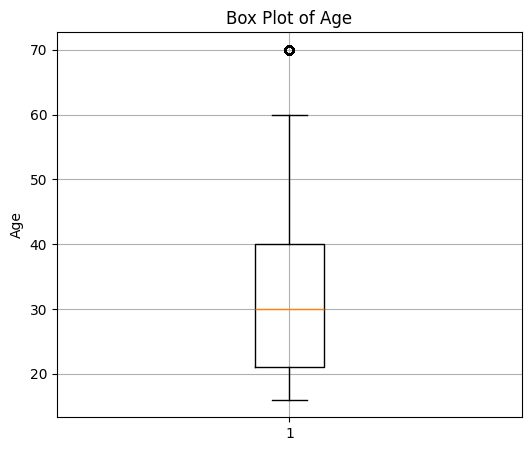

In [8]:
## Write your code here
def age_to_numeric(age):
    if pd.isnull(age) or age == 'Prefer not to say':
        return None
    if age == 'Under 18 years old':
        return 16
    elif age == '18-24 years old':
        return 21
    elif age == '25-34 years old':
        return 30
    elif age == '35-44 years old':
        return 40
    elif age == '45-54 years old':
        return 50
    elif age == '55-64 years old':
        return 60
    else:
        return 70

df['Age_numeric'] = df['Age'].apply(age_to_numeric)
age_data = df['Age_numeric'].dropna()
plt.figure(figsize=(6,5))

plt.boxplot(age_data)

plt.title("Box Plot of Age")
plt.ylabel("Age")
plt.grid(True)

plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



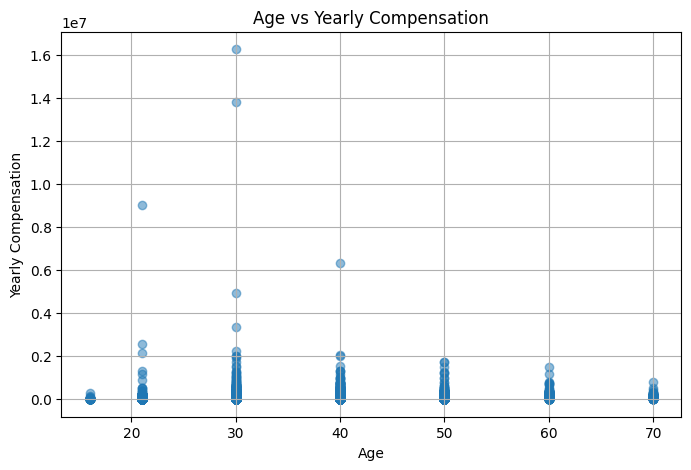

In [9]:
## Write your code here
df_scatter = df[['Age_numeric', 'ConvertedCompYearly']].dropna()
plt.figure(figsize=(8,5))

plt.scatter(
    df_scatter['Age_numeric'],
    df_scatter['ConvertedCompYearly'],
    alpha=0.5   # makes points slightly transparent
)

plt.title("Age vs Yearly Compensation")
plt.xlabel("Age")
plt.ylabel("Yearly Compensation")
plt.grid(True)

plt.show()

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


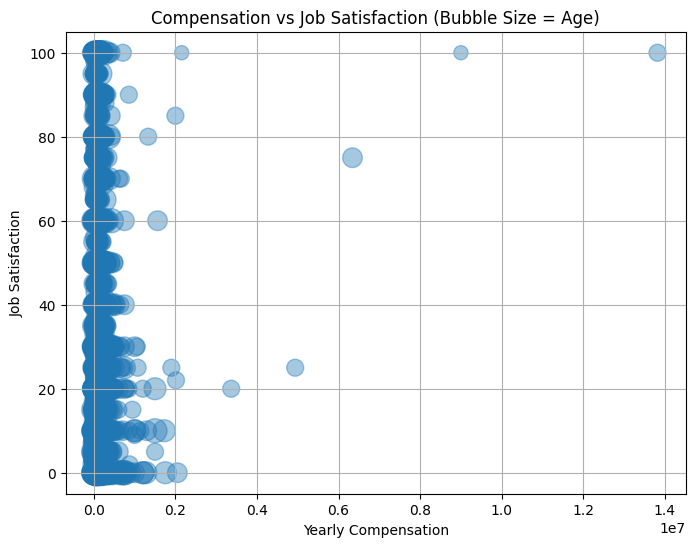

In [11]:
## Write your code here
df_bubble = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age_numeric']].dropna()
bubble_size = df_bubble['Age_numeric'] * 5
plt.figure(figsize=(8,6))

plt.scatter(
    df_bubble['ConvertedCompYearly'],
    df_bubble['JobSatPoints_6'],
    s=bubble_size,
    alpha=0.4
)

plt.title("Compensation vs Job Satisfaction (Bubble Size = Age)")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")
plt.grid(True)

plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64


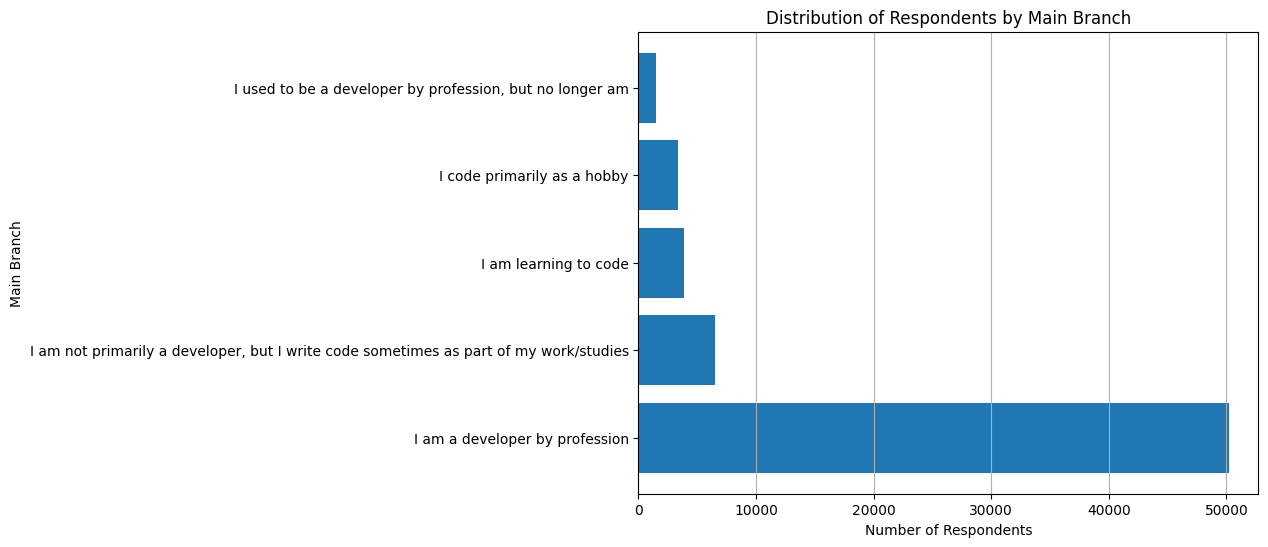

In [13]:
## Write your code here
mainbranch_data = df['MainBranch'].dropna()

# Count occurrences of each category
mainbranch_counts = mainbranch_data.value_counts()

print(mainbranch_counts)
plt.figure(figsize=(8,6))

plt.barh(
    mainbranch_counts.index,
    mainbranch_counts.values
)

plt.title("Distribution of Respondents by Main Branch")
plt.xlabel("Number of Respondents")
plt.ylabel("Main Branch")
plt.grid(axis='x')

plt.show()

##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



LanguageWantToWorkWith
Python        25047
JavaScript    23774
SQL           22400
HTML/CSS      20721
TypeScript    20239
Name: count, dtype: int64


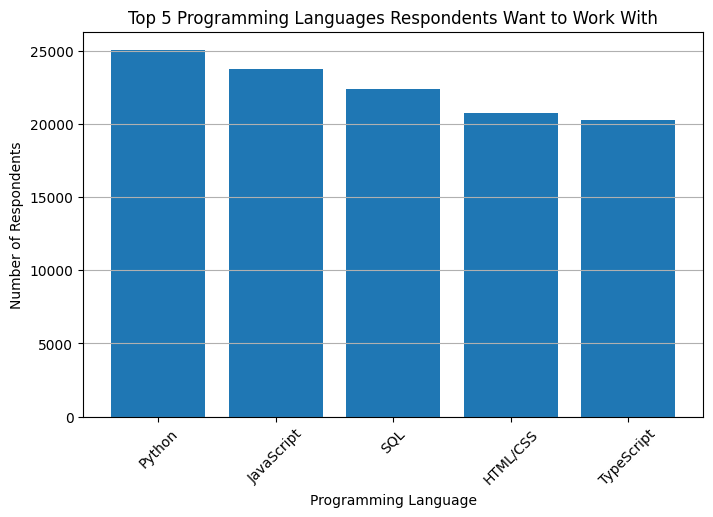

In [14]:
## Write your code here
lang_data = df['LanguageWantToWorkWith'].dropna()

# Split multiple languages into separate rows
lang_split = lang_data.str.split(';')

# Explode the list into individual rows
lang_exploded = lang_split.explode()
top5_languages = lang_exploded.value_counts().head(5)

print(top5_languages)
plt.figure(figsize=(8,5))

plt.bar(
    top5_languages.index,
    top5_languages.values
)

plt.title("Top 5 Programming Languages Respondents Want to Work With")
plt.xlabel("Programming Language")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


   Age_numeric  JobSatPoints_6  JobSatPoints_7
0         16.0             1.5             5.0
1         21.0            15.0            20.0
2         30.0            20.0            15.0
3         40.0            20.0            15.0
4         50.0            20.0            15.0
5         60.0            20.0            20.0
6         70.0            20.0            15.0


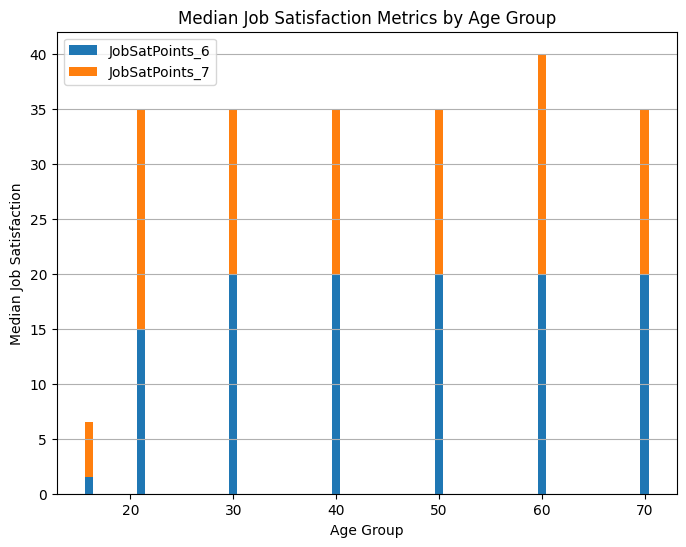

In [15]:
## Write your code here
# Keep relevant columns and drop missing values
df_jobsat = df[['Age_numeric', 'JobSatPoints_6', 'JobSatPoints_7']].dropna()
median_jobsat_by_age = df_jobsat.groupby('Age_numeric')[['JobSatPoints_6', 'JobSatPoints_7']].median().reset_index()
print(median_jobsat_by_age)
plt.figure(figsize=(8,6))

# First layer (JobSatPoints_6)
plt.bar(
    median_jobsat_by_age['Age_numeric'],
    median_jobsat_by_age['JobSatPoints_6'],
    label='JobSatPoints_6'
)

# Second layer stacked on top
plt.bar(
    median_jobsat_by_age['Age_numeric'],
    median_jobsat_by_age['JobSatPoints_7'],
    bottom=median_jobsat_by_age['JobSatPoints_6'],
    label='JobSatPoints_7'
)

plt.title("Median Job Satisfaction Metrics by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Job Satisfaction")
plt.legend()
plt.grid(axis='y')

plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



DatabaseHaveWorkedWith
PostgreSQL              25536
MySQL                   21099
SQLite                  17365
Microsoft SQL Server    13275
MongoDB                 13007
Redis                   10463
MariaDB                  8991
Elasticsearch            6533
Oracle                   5273
Dynamodb                 4138
Name: count, dtype: int64


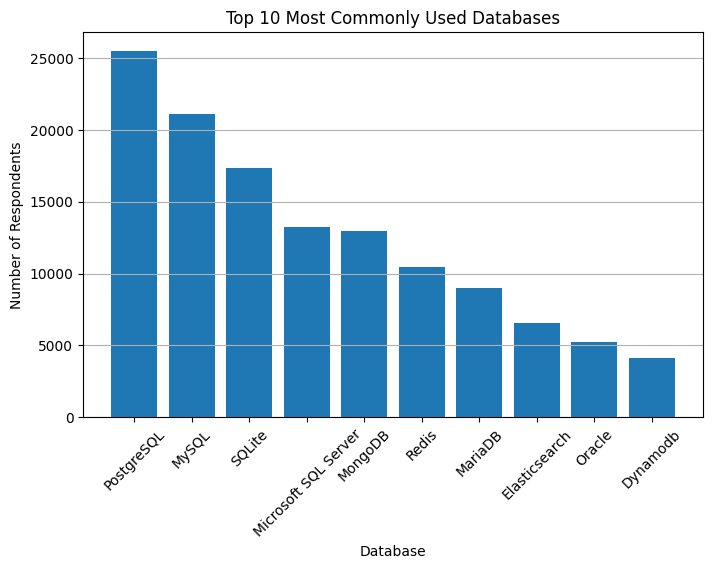

In [16]:
## Write your code here
# Drop missing values
db_data = df['DatabaseHaveWorkedWith'].dropna()

# Split multiple databases into lists
db_split = db_data.str.split(';')

# Explode into separate rows
db_exploded = db_split.explode()
top_databases = db_exploded.value_counts().head(10)
print(top_databases)
plt.figure(figsize=(8,5))

plt.bar(
    top_databases.index,
    top_databases.values
)

plt.title("Top 10 Most Commonly Used Databases")
plt.xlabel("Database")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



   Age_numeric  ConvertedCompYearly
0         16.0               7626.5
1         21.0              25000.0
2         30.0              59825.0
3         40.0              84796.0
4         50.0              99099.0
5         60.0             109691.0
6         70.0             106000.0


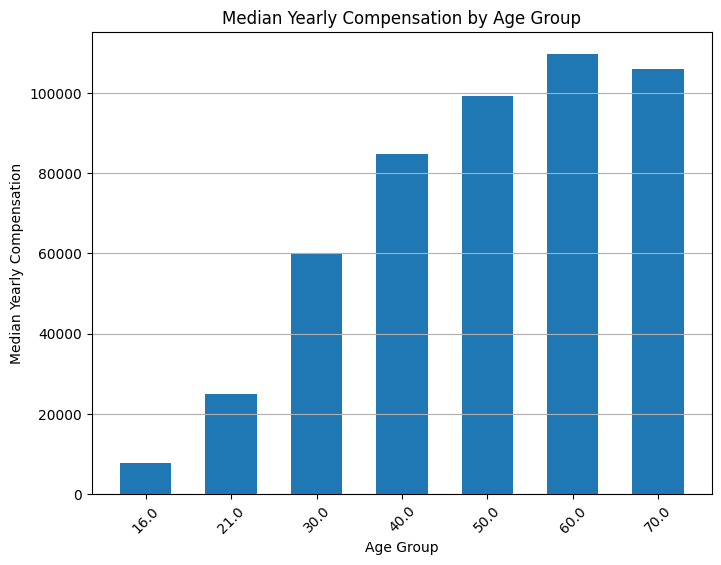

In [17]:
## Write your code here
# Remove missing values
df_comp = df[['Age_numeric', 'ConvertedCompYearly']].dropna()
median_comp_by_age = df_comp.groupby('Age_numeric')['ConvertedCompYearly'].median().reset_index()
print(median_comp_by_age)
plt.figure(figsize=(8,6))

x_positions = range(len(median_comp_by_age))

plt.bar(
    x_positions,
    median_comp_by_age['ConvertedCompYearly'],
    width=0.6
)

plt.xticks(
    x_positions,
    median_comp_by_age['Age_numeric'],
    rotation=45
)

plt.title("Median Yearly Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Yearly Compensation")
plt.grid(axis='y')

plt.show()

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
                                                        ...  
Haiti                                                       1
Nauru                                                       1
Chad                                                        1
Djibouti                                                    1
Solomon Islands                                             1
Name: count, Length: 185, dtype: int64


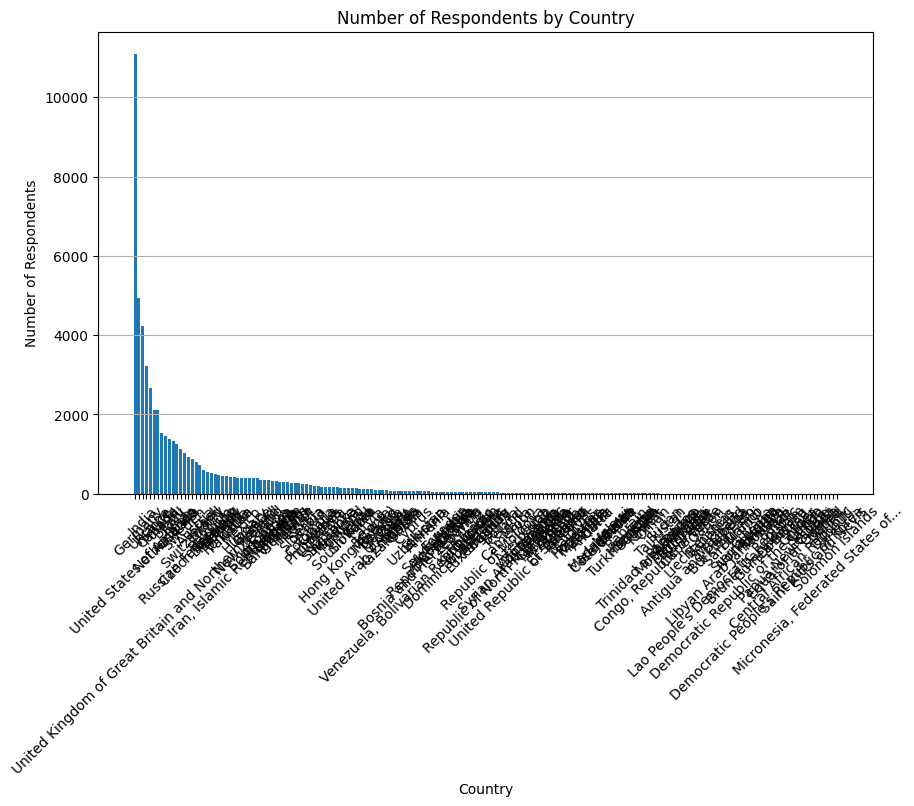

In [18]:
## Write your code here
# Drop missing values
country_data = df['Country'].dropna()

# Count respondents per country
country_counts = country_data.value_counts()

print(country_counts)
plt.figure(figsize=(10,6))

plt.bar(
    country_counts.index,
    country_counts.values
)

plt.title("Number of Respondents by Country")
plt.xlabel("Country")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
